In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pygame
import random
import time
import matplotlib.pyplot as plt
from collections import deque

# ==============================================================================
# CLEANING ROBOT ENVIRONMENT (STABLE & CORRECT)
# ==============================================================================

class CleaningRobotEnv(gym.Env):

    metadata = {"render_modes": ["human"], "render_fps": 8}

    def __init__(self, render_mode=None):
        super().__init__()

        self.grid_size = 5
        self.render_mode = render_mode
        self.window_size = 500
        self.cell_size = self.window_size // self.grid_size

        self.action_space = spaces.Discrete(4)

        # Fixed dirt positions
        self.dirt_positions = [(0,4), (2,2), (4,4), (4,0)]
        self.num_dirt = len(self.dirt_positions)

        # State = row, col, cleaned_mask
        self.observation_space = spaces.MultiDiscrete(
            [self.grid_size, self.grid_size, 2**self.num_dirt]
        )

        self.walls = [(1,1), (3,1), (2,3)]

        self.window = None
        self.clock = None
        self.font = None

        self.reset()

    # --------------------------------------------------------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = np.array([0,0])
        self.cleaned_mask = 0
        return self._get_obs(), {}

    # --------------------------------------------------------------------------

    def _get_obs(self):
        return np.array([
            self.agent_pos[0],
            self.agent_pos[1],
            self.cleaned_mask
        ])

    # --------------------------------------------------------------------------

    def step(self, action):

        directions = {
            0: np.array([-1,0]),
            1: np.array([0,1]),
            2: np.array([1,0]),
            3: np.array([0,-1])
        }

        reward = -1
        new_pos = self.agent_pos + directions[action]

        # Check boundaries and walls
        if (0 <= new_pos[0] < self.grid_size and
            0 <= new_pos[1] < self.grid_size and
            tuple(new_pos) not in self.walls):
            self.agent_pos = new_pos
        else:
            reward -= 5

        # Cleaning logic
        for i, dirt in enumerate(self.dirt_positions):
            if tuple(self.agent_pos) == dirt:
                if not (self.cleaned_mask & (1 << i)):
                    reward += 20
                    self.cleaned_mask |= (1 << i)

        terminated = False

        # If all cleaned AND back home
        if self.cleaned_mask == (2**self.num_dirt - 1):
            if tuple(self.agent_pos) == (0,0):
                reward += 100
                terminated = True

        return self._get_obs(), reward, terminated, False, {}

    # --------------------------------------------------------------------------

    def render(self, episode=None):

        if self.window is None:
            pygame.init()
            self.window = pygame.display.set_mode(
                (self.window_size, self.window_size)
            )
            self.clock = pygame.time.Clock()
            self.font = pygame.font.SysFont("Arial", 18)

        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((255,255,255))

        # Draw grid
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                rect = pygame.Rect(
                    c*self.cell_size,
                    r*self.cell_size,
                    self.cell_size,
                    self.cell_size
                )
                if (r,c) in self.walls:
                    pygame.draw.rect(canvas, (0,0,0), rect)
                else:
                    pygame.draw.rect(canvas, (255,255,255), rect)
                pygame.draw.rect(canvas, (200,200,200), rect, 1)

        # Draw dirt
        for i, dirt in enumerate(self.dirt_positions):
            if not (self.cleaned_mask & (1 << i)):
                pygame.draw.rect(
                    canvas,
                    (139,69,19),
                    pygame.Rect(
                        dirt[1]*self.cell_size,
                        dirt[0]*self.cell_size,
                        self.cell_size,
                        self.cell_size
                    )
                )

        # Draw robot
        pygame.draw.circle(
            canvas,
            (0,0,255),
            (
                int((self.agent_pos[1]+0.5)*self.cell_size),
                int((self.agent_pos[0]+0.5)*self.cell_size)
            ),
            self.cell_size//3
        )

        # Display episode number
        if episode is not None:
            text = self.font.render(f"Episode: {episode}", True, (0,0,0))
            canvas.blit(text, (10,10))

        self.window.blit(canvas, canvas.get_rect())
        pygame.display.update()
        pygame.event.pump()
        self.clock.tick(self.metadata["render_fps"])

    def close(self):
        if self.window:
            pygame.quit()

# ==============================================================================
# TRAINING WITH EARLY STOPPING + LIVE VISUALIZATION
# ==============================================================================

def train_robot():

    env = CleaningRobotEnv(render_mode=None)
    q_table = np.zeros((5,5,16,4))

    episodes = 8000
    alpha = 0.1
    gamma = 0.95
    epsilon = 1.0
    min_epsilon = 0.05
    decay = 0.0007

    max_steps = 200
    rewards_history = []
    moving_avg = deque(maxlen=200)

    best_avg = -np.inf
    patience = 20
    no_improve_counter = 0

    render_every = 500

    for episode in range(episodes):

        state,_ = env.reset()
        total_reward = 0
        done = False
        step_count = 0

        while not done and step_count < max_steps:

            r,c,mask = state

            if random.uniform(0,1) < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[r,c,mask])

            next_state, reward, done,_,_ = env.step(action)
            nr,nc,nmask = next_state

            old = q_table[r,c,mask,action]
            next_max = np.max(q_table[nr,nc,nmask])

            q_table[r,c,mask,action] = old + alpha*(reward + gamma*next_max - old)

            state = next_state
            total_reward += reward
            step_count += 1

            # Render occasionally during training
            if episode % render_every == 0:
                env.render(episode)

        epsilon = max(min_epsilon, epsilon*np.exp(-decay))
        rewards_history.append(total_reward)
        moving_avg.append(total_reward)

        avg_reward = np.mean(moving_avg)

        print(f"Episode {episode} | Reward: {total_reward:.2f} | Avg: {avg_reward:.2f} | Epsilon: {epsilon:.3f}")

        # Early stopping check
        if avg_reward > best_avg + 1e-3:
            best_avg = avg_reward
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        if no_improve_counter >= patience:
            print("\n🛑 Early stopping: No improvement detected.")
            break

    env.close()

    # Plot training curve
    plt.plot(rewards_history)
    plt.title("Training Reward Progress")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()

    return q_table

# ==============================================================================
# FINAL DEMO (FULL GREEDY POLICY)
# ==============================================================================

def demo(q_table):

    env = CleaningRobotEnv(render_mode="human")
    state,_ = env.reset()
    done = False
    max_steps = 200
    step_count = 0

    while not done and step_count < max_steps:
        r,c,mask = state
        action = np.argmax(q_table[r,c,mask])
        state,_,done,_,_ = env.step(action)
        env.render("FINAL POLICY")
        step_count += 1

    time.sleep(3)
    env.close()


# if __name__ == "__main__":
#     q = train_robot()
#     demo(q)

Episode 0 | Reward: -414.00 | Avg: -414.00 | Epsilon: 0.999
Episode 1 | Reward: -435.00 | Avg: -424.50 | Epsilon: 0.999
Episode 2 | Reward: -465.00 | Avg: -438.00 | Epsilon: 0.998
Episode 3 | Reward: -525.00 | Avg: -459.75 | Epsilon: 0.997
Episode 4 | Reward: -525.00 | Avg: -472.80 | Epsilon: 0.997
Episode 5 | Reward: -470.00 | Avg: -472.33 | Epsilon: 0.996
Episode 6 | Reward: -565.00 | Avg: -485.57 | Epsilon: 0.995
Episode 7 | Reward: -450.00 | Avg: -481.12 | Epsilon: 0.994
Episode 8 | Reward: -495.00 | Avg: -482.67 | Epsilon: 0.994
Episode 9 | Reward: -430.00 | Avg: -477.40 | Epsilon: 0.993
Episode 10 | Reward: -226.00 | Avg: -454.55 | Epsilon: 0.992
Episode 11 | Reward: -495.00 | Avg: -457.92 | Epsilon: 0.992
Episode 12 | Reward: -242.00 | Avg: -441.31 | Epsilon: 0.991
Episode 13 | Reward: -174.00 | Avg: -422.21 | Epsilon: 0.990
Episode 14 | Reward: -148.00 | Avg: -403.93 | Epsilon: 0.990
Episode 15 | Reward: -505.00 | Avg: -410.25 | Epsilon: 0.989
Episode 16 | Reward: -288.00 | Avg

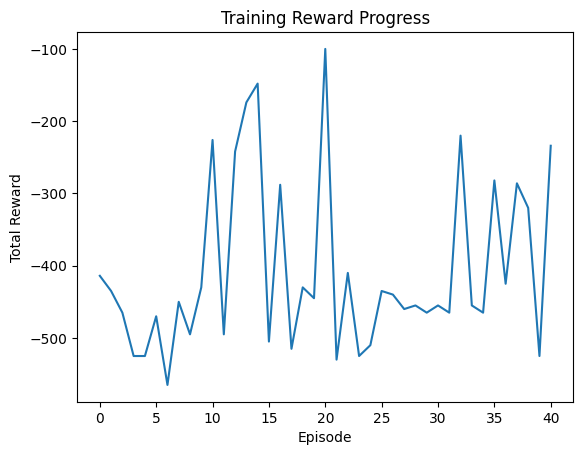

In [9]:
if __name__ == "__main__":
    q = train_robot()
    demo(q)